# Experiment A — Baseline Logistic Regression

This experiment evaluates the original baseline feature set using logistic regression for diabetes-status classification in the CCHS 2022 modelling population.

The experiment uses the same target definition, train/validation/test split, CCHS special-value handling, and preprocessing framework established during the controlled experiment setup.

The validation set is used for model and threshold decisions. The test set is kept untouched until the final evaluation.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
pumf = pd.read_csv("pumf_cchs.csv")

print("PUMF shape:", pumf.shape)

PUMF shape: (67079, 255)


In [3]:
target_counts = pumf["CCC_05"].value_counts(dropna=False).sort_index()

print("Diabetes = 1:", target_counts.get(1, 0))
print("No diabetes = 2:", target_counts.get(2, 0))
print("Not stated = 9:", target_counts.get(9, 0))

Diabetes = 1: 5994
No diabetes = 2: 60248
Not stated = 9: 837


In [4]:
model_data = pumf[pumf["CCC_05"].isin([1, 2])].copy()

model_data["target"] = (model_data["CCC_05"] == 1).astype(int)

print("Modelling population:", model_data.shape[0])
print(model_data["target"].value_counts().sort_index())

Modelling population: 66242
target
0    60248
1     5994
Name: count, dtype: int64


In [5]:
FEATURES = [
    "DHHGAGE",
    "DHH_SEX",
    "GEOGPRV",
    "DHHDGHSZ",
    "EDDVH3",
    "LSM_01",
    "HWTDGISW",
    "WTP_50",
    "SMKDVSTY",
    "FSCDVHF2",
    "INCDGHH"
]

print("Number of baseline features:", len(FEATURES))
print("Baseline features:")
print(FEATURES)

Number of baseline features: 11
Baseline features:
['DHHGAGE', 'DHH_SEX', 'GEOGPRV', 'DHHDGHSZ', 'EDDVH3', 'LSM_01', 'HWTDGISW', 'WTP_50', 'SMKDVSTY', 'FSCDVHF2', 'INCDGHH']


In [6]:
SPECIAL_CODES = {
    "DHHDGHSZ": [9],
    "EDDVH3": [9],
    "FSCDVHF2": [9],
    "INCDGHH": [9],
    "LSM_01": [99],
    "SMKDVSTY": [96, 99],
    "HWTDGISW": [6, 9],
    "WTP_50": [9]
}

def apply_special_codes(df, special_codes):
    result = df.copy()

    for column, codes in special_codes.items():
        if column in result.columns:
            result[column] = result[column].replace(codes, np.nan)

    return result

clean_model_data = apply_special_codes(model_data, SPECIAL_CODES)

print("Special-value handling applied.")

Special-value handling applied.


In [7]:
RANDOM_STATE = 42

train_val_idx, test_idx = train_test_split(
    model_data.index,
    test_size=0.20,
    stratify=model_data["target"],
    random_state=RANDOM_STATE
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.20,
    stratify=model_data.loc[train_val_idx, "target"],
    random_state=RANDOM_STATE
)

print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nTarget prevalence:")
print(f"Training:   {model_data.loc[train_idx, 'target'].mean():.3%}")
print(f"Validation: {model_data.loc[val_idx, 'target'].mean():.3%}")
print(f"Test:       {model_data.loc[test_idx, 'target'].mean():.3%}")

Training: 42394
Validation: 10599
Test: 13249

Target prevalence:
Training:   9.048%
Validation: 9.048%
Test:       9.050%


In [8]:
X_train = clean_model_data.loc[train_idx, FEATURES]
X_val = clean_model_data.loc[val_idx, FEATURES]
X_test = clean_model_data.loc[test_idx, FEATURES]

y_train = model_data.loc[train_idx, "target"]
y_val = model_data.loc[val_idx, "target"]
y_test = model_data.loc[test_idx, "target"]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (42394, 11) (42394,)
Validation: (10599, 11) (10599,)
Test: (13249, 11) (13249,)


In [9]:
NUMERIC_FEATURES = ["LSM_01"]
CATEGORICAL_FEATURES = [
    feature for feature in FEATURES
    if feature not in NUMERIC_FEATURES
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES)
])

In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Raw training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Raw training shape: (42394, 11)
Processed training shape: (42394, 44)
Processed validation shape: (10599, 44)
Processed test shape: (13249, 44)


In [11]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [12]:
train_prob = logistic_model.predict_proba(X_train_processed)[:, 1]
val_prob = logistic_model.predict_proba(X_val_processed)[:, 1]
test_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predicted probabilities generated successfully.")
print("Training:", train_prob.shape)
print("Validation:", val_prob.shape)
print("Test:", test_prob.shape)

Predicted probabilities generated successfully.
Training: (42394,)
Validation: (10599,)
Test: (13249,)


In [13]:
train_pred_default = (train_prob >= 0.5).astype(int)
val_pred_default = (val_prob >= 0.5).astype(int)
test_pred_default = (test_prob >= 0.5).astype(int)

def evaluate_predictions(y_true, y_pred, y_prob, split_name):
    print(f"\n{split_name}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.3f}")
    print(f"PR-AUC:    {average_precision_score(y_true, y_prob):.3f}")

    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate_predictions(
    y_train, train_pred_default, train_prob, "Training"
)

evaluate_predictions(
    y_val, val_pred_default, val_prob, "Validation"
)

evaluate_predictions(
    y_test, test_pred_default, test_prob, "Test"
)


Training
Accuracy:  0.656
Precision: 0.181
Recall:    0.798
F1-score:  0.296
ROC-AUC:   0.783
PR-AUC:    0.228
Confusion matrix:
[[24727 13831]
 [  773  3063]]

Validation
Accuracy:  0.656
Precision: 0.181
Recall:    0.797
F1-score:  0.295
ROC-AUC:   0.783
PR-AUC:    0.244
Confusion matrix:
[[6189 3451]
 [ 195  764]]

Test
Accuracy:  0.653
Precision: 0.177
Recall:    0.778
F1-score:  0.288
ROC-AUC:   0.782
PR-AUC:    0.247
Confusion matrix:
[[7713 4337]
 [ 266  933]]


This default threshold check is descriptive only and does not inform any downstream decision

In [14]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    val_pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "accuracy": accuracy_score(y_val, val_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

print(threshold_results.round(3).to_string(index=False))

 threshold  precision  recall    f1  accuracy
      0.10      0.112   0.990 0.202     0.292
      0.15      0.120   0.981 0.214     0.347
      0.20      0.126   0.976 0.223     0.386
      0.25      0.133   0.959 0.234     0.431
      0.30      0.140   0.934 0.244     0.476
      0.35      0.149   0.916 0.256     0.519
      0.40      0.158   0.895 0.269     0.560
      0.45      0.167   0.850 0.279     0.603
      0.50      0.181   0.797 0.295     0.656
      0.55      0.193   0.722 0.304     0.701
      0.60      0.205   0.636 0.310     0.744
      0.65      0.217   0.532 0.308     0.784
      0.70      0.238   0.423 0.305     0.825
      0.75      0.274   0.282 0.277     0.867
      0.80      0.332   0.138 0.195     0.897
      0.85      0.375   0.034 0.063     0.907
      0.90      0.571   0.004 0.008     0.910


In [15]:
fine_thresholds = np.arange(0.50, 0.701, 0.005)

fine_threshold_results = []

for threshold in fine_thresholds:
    val_pred = (val_prob >= threshold).astype(int)

    fine_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "accuracy": accuracy_score(y_val, val_pred)
    })

fine_threshold_results = pd.DataFrame(fine_threshold_results)

best_threshold_row = fine_threshold_results.loc[
    fine_threshold_results["f1"].idxmax()
]

print("Best validation threshold based on F1:")
print(best_threshold_row.round(4).to_string())

Best validation threshold based on F1:
threshold    0.5700
precision    0.2013
recall       0.7018
f1           0.3128
accuracy     0.7210


In [16]:
FINAL_THRESHOLD = float(best_threshold_row["threshold"])

print(f"Final threshold selected from validation data: {FINAL_THRESHOLD:.3f}")

Final threshold selected from validation data: 0.570


In [17]:
final_test_pred = (test_prob >= FINAL_THRESHOLD).astype(int)

print("Final Test Results")
print(f"Threshold: {FINAL_THRESHOLD:.3f}")
print(f"Accuracy:  {accuracy_score(y_test, final_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, final_test_pred, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, final_test_pred, zero_division=0):.3f}")
print(f"F1-score:  {f1_score(y_test, final_test_pred, zero_division=0):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, test_prob):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, test_prob):.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, final_test_pred))

Final Test Results
Threshold: 0.570
Accuracy:  0.721
Precision: 0.199
Recall:    0.690
F1-score:  0.309
ROC-AUC:   0.782
PR-AUC:    0.247

Confusion matrix:
[[8726 3324]
 [ 372  827]]


In [18]:
experiment_a_results = pd.DataFrame([{
    "experiment": "A_Baseline",
    "model": "Logistic Regression",
    "threshold": FINAL_THRESHOLD,
    "accuracy": accuracy_score(y_test, final_test_pred),
    "precision": precision_score(y_test, final_test_pred, zero_division=0),
    "recall": recall_score(y_test, final_test_pred, zero_division=0),
    "f1": f1_score(y_test, final_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_prob),
    "pr_auc": average_precision_score(y_test, test_prob)
}])

experiment_a_results

,experiment,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,A_Baseline,Logistic Regression,0.57,0.721036,0.199229,0.689741,0.309159,0.781763,0.246731


In [19]:
tn, fp, fn, tp = confusion_matrix(y_test, final_test_pred).ravel()

print("Final Test Confusion Matrix Components")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

Final Test Confusion Matrix Components
True Negatives (TN):  8726
False Positives (FP): 3324
False Negatives (FN): 372
True Positives (TP):  827


In [20]:
test_results = clean_model_data.loc[
    test_idx,
    FEATURES
].copy()

test_results["actual"] = y_test.values
test_results["predicted"] = final_test_pred
test_results["probability"] = test_prob

test_results["error_type"] = np.select(
    [
        (test_results["actual"] == 1) & (test_results["predicted"] == 0),
        (test_results["actual"] == 0) & (test_results["predicted"] == 1)
    ],
    [
        "False Negative",
        "False Positive"
    ],
    default="Correct"
)

print("Error counts:")
print(test_results["error_type"].value_counts())

print("\nFalse Negative count:", (test_results["error_type"] == "False Negative").sum())
print("False Positive count:", (test_results["error_type"] == "False Positive").sum())

Error counts:
error_type
Correct           9553
False Positive    3324
False Negative     372
Name: count, dtype: int64

False Negative count: 372
False Positive count: 3324


In [22]:
for variable in ["DHHGAGE", "DHH_SEX", "HWTDGISW", "SMKDVSTY"]:
    print(f"\n{variable} distribution by error type:")
    print(
        pd.crosstab(
            test_results["error_type"],
            test_results[variable],
            normalize="index"
        ).round(3)
    )


DHHGAGE distribution by error type:
DHHGAGE             1     2      3      4      5
error_type                                      
Correct         0.082  0.21  0.257  0.229  0.222
False Negative  0.016  0.07  0.161  0.374  0.379
False Positive  0.000  0.00  0.002  0.236  0.763

DHH_SEX distribution by error type:
DHH_SEX             1      2
error_type                  
Correct         0.430  0.570
False Negative  0.449  0.551
False Positive  0.577  0.423

HWTDGISW distribution by error type:
HWTDGISW          1.0    2.0
error_type                  
Correct         0.510  0.490
False Negative  0.556  0.444
False Positive  0.093  0.907

SMKDVSTY distribution by error type:
SMKDVSTY          1.0    2.0    3.0    4.0    5.0    6.0
error_type                                              
Correct         0.112  0.016  0.228  0.031  0.123  0.490
False Negative  0.121  0.023  0.279  0.031  0.115  0.431
False Positive  0.065  0.001  0.390  0.032  0.090  0.423


In [24]:
error_probability_summary = (
    test_results[test_results["error_type"].isin(["False Positive", "False Negative"])]
    .groupby("error_type")["probability"]
    .agg(["count", "mean", "min", "max"])
)

print("Predicted-probability summary for errors:")
print(error_probability_summary.round(3))

Predicted-probability summary for errors:
                count   mean    min    max
error_type                                
False Negative    372  0.395  0.013  0.569
False Positive   3324  0.699  0.570  0.919


In [25]:
BORDERLINE_MARGIN = 0.05

borderline_false_negatives = (
    (test_results["error_type"] == "False Negative") &
    (test_results["probability"] >= FINAL_THRESHOLD - BORDERLINE_MARGIN)
).sum()

borderline_false_positives = (
    (test_results["error_type"] == "False Positive") &
    (test_results["probability"] <= FINAL_THRESHOLD + BORDERLINE_MARGIN)
).sum()

false_negative_total = (
    test_results["error_type"] == "False Negative"
).sum()

false_positive_total = (
    test_results["error_type"] == "False Positive"
).sum()

print(
    f"False negatives within {BORDERLINE_MARGIN:.2f} of threshold: "
    f"{borderline_false_negatives} / {false_negative_total} "
    f"({borderline_false_negatives / false_negative_total:.1%})"
)

print(
    f"False positives within {BORDERLINE_MARGIN:.2f} of threshold: "
    f"{borderline_false_positives} / {false_positive_total} "
    f"({borderline_false_positives / false_positive_total:.1%})"
)

False negatives within 0.05 of threshold: 77 / 372 (20.7%)
False positives within 0.05 of threshold: 659 / 3324 (19.8%)


In [26]:
false_negatives = (
    test_results[test_results["error_type"] == "False Negative"]
    .sort_values("probability", ascending=True)
)

false_positives = (
    test_results[test_results["error_type"] == "False Positive"]
    .sort_values("probability", ascending=False)
)

print("Most confident false negatives:")
display(
    false_negatives[
        FEATURES + ["actual", "predicted", "probability"]
    ].head(10)
)

print("\nMost confident false positives:")
display(
    false_positives[
        FEATURES + ["actual", "predicted", "probability"]
    ].head(10)
)

Most confident false negatives:


,DHHGAGE,DHH_SEX,GEOGPRV,DHHDGHSZ,EDDVH3,LSM_01,HWTDGISW,WTP_50,SMKDVSTY,FSCDVHF2,INCDGHH,actual,predicted,probability
8164,2,1,59,2.0,3.0,6.0,1.0,3.0,2.0,0.0,5.0,1,0,0.012541
26151,2,2,46,1.0,3.0,8.0,1.0,3.0,6.0,0.0,4.0,1,0,0.017426
61318,2,2,59,2.0,3.0,6.0,1.0,3.0,6.0,0.0,5.0,1,0,0.019332
56711,2,2,48,2.0,3.0,7.0,1.0,3.0,6.0,0.0,5.0,1,0,0.028440
66785,2,2,35,2.0,3.0,7.0,1.0,1.0,3.0,0.0,5.0,1,0,0.031912
27932,2,2,35,2.0,3.0,8.0,1.0,1.0,6.0,0.0,5.0,1,0,0.033782
20363,1,2,13,2.0,3.0,7.0,NaN,3.0,NaN,0.0,5.0,1,0,0.038565
46336,2,2,48,2.0,3.0,8.0,1.0,3.0,6.0,2.0,5.0,1,0,0.042877
45007,2,2,48,2.0,3.0,7.0,2.0,1.0,2.0,1.0,5.0,1,0,0.047391
56058,2,2,35,2.0,3.0,9.0,2.0,1.0,1.0,0.0,5.0,1,0,0.047723



Most confident false positives:


,DHHGAGE,DHH_SEX,GEOGPRV,DHHDGHSZ,EDDVH3,LSM_01,HWTDGISW,WTP_50,SMKDVSTY,FSCDVHF2,INCDGHH,actual,predicted,probability
32158,5,1,46,2.0,2.0,0.0,2.0,1.0,3.0,3.0,2.0,0,1,0.919036
60774,5,1,35,1.0,1.0,3.0,2.0,1.0,3.0,2.0,1.0,0,1,0.915394
50816,5,1,35,1.0,3.0,0.0,NaN,1.0,6.0,2.0,2.0,0,1,0.914718
13808,5,1,35,1.0,1.0,1.0,2.0,3.0,6.0,3.0,3.0,0,1,0.908315
65071,5,1,48,2.0,2.0,8.0,2.0,1.0,3.0,2.0,3.0,0,1,0.903763
20017,5,1,48,2.0,2.0,2.0,2.0,1.0,6.0,0.0,2.0,0,1,0.903394
47064,5,1,10,2.0,3.0,8.0,2.0,1.0,3.0,2.0,1.0,0,1,0.901848
49573,5,1,35,1.0,1.0,1.0,2.0,1.0,3.0,1.0,3.0,0,1,0.901452
39454,5,1,24,1.0,1.0,8.0,2.0,1.0,6.0,2.0,2.0,0,1,0.900812
12038,5,1,10,2.0,1.0,5.0,2.0,1.0,3.0,0.0,2.0,0,1,0.899897


## Failure Case Observations

The final test evaluation shows both false negatives and false positives, with 372 and 3,324 cases respectively.

The error analysis indicates that these errors are not limited to observations close to the decision threshold. Approximately one fifth of each error type falls within 0.05 of the selected threshold, while the remaining errors are farther from the decision boundary.

The most confident false negatives have predicted probabilities well below the final threshold, while the most confident false positives have probabilities substantially above it. This indicates that some observations are misclassified with relatively high model confidence.

The descriptive error distributions also show concentration in particular age and BMI categories, especially among false positives. These patterns describe where errors occur in the test data, but they do not establish causal explanations for why individual respondents were misclassified.

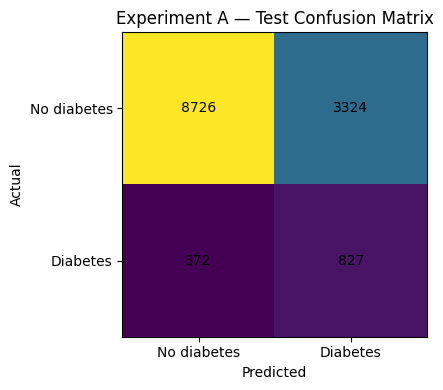

In [27]:
cm = confusion_matrix(y_test, final_test_pred)

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm)

ax.set_title("Experiment A — Test Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No diabetes", "Diabetes"])
ax.set_yticklabels(["No diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

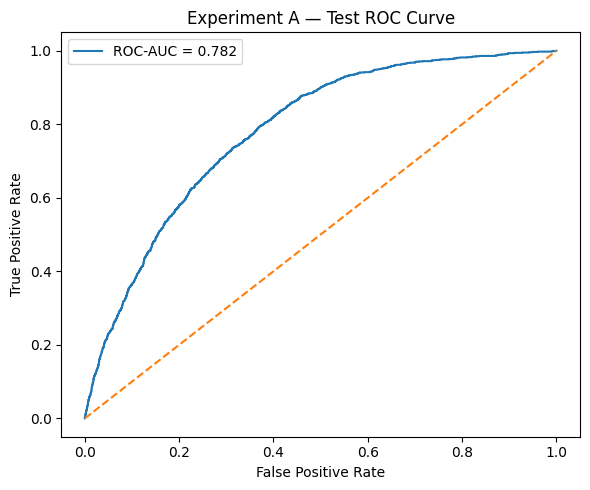

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Experiment A — Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

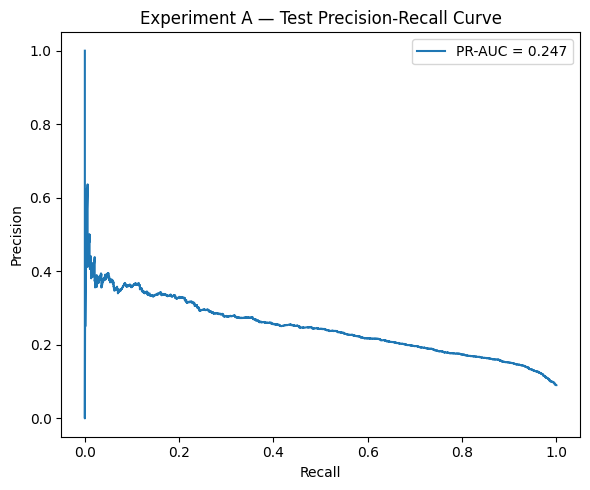

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {average_precision_score(y_test, test_prob):.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Experiment A — Test Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
experiment_a_results.to_csv(
    "experiment_A_results.csv",
    index=False
)

print("Saved: experiment_A_results.csv")

Saved: experiment_A_results.csv


In [31]:
from sklearn.metrics import log_loss

train_log_loss = log_loss(y_train, train_prob)
val_log_loss = log_loss(y_val, val_prob)
test_log_loss = log_loss(y_test, test_prob)

print("Log Loss")
print(f"Training:   {train_log_loss:.4f}")
print(f"Validation: {val_log_loss:.4f}")
print(f"Test:       {test_log_loss:.4f}")

Log Loss
Training:   0.5656
Validation: 0.5694
Test:       0.5658


In [32]:
experiment_a_results["train_log_loss"] = train_log_loss
experiment_a_results["validation_log_loss"] = val_log_loss
experiment_a_results["test_log_loss"] = test_log_loss

experiment_a_results

,experiment,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,train_log_loss,validation_log_loss,test_log_loss
0,A_Baseline,Logistic Regression,0.57,0.721036,0.199229,0.689741,0.309159,0.781763,0.246731,0.565628,0.569432,0.565837


In [33]:
experiment_a_results.to_csv(
    "experiment_A_results.csv",
    index=False
)

print("Updated: experiment_A_results.csv")

Updated: experiment_A_results.csv


## Experiment A — Final Summary

The baseline Logistic Regression model was trained using the predefined 11-feature baseline condition.

The decision threshold was selected using validation-set F1 and fixed at 0.570 before final test evaluation.

On the untouched test set, the model achieved 72.1% accuracy, 19.9% precision, 69.0% recall, 30.9% F1-score, 0.782 ROC-AUC, and 0.247 PR-AUC.

The test confusion matrix contained 8,726 true negatives, 3,324 false positives, 372 false negatives, and 827 true positives.

The training, validation, and test log-loss values were 0.5656, 0.5694, and 0.5658 respectively, showing similar probability-level performance across the three splits.

Failure analysis showed that errors were present both near the decision threshold and farther from it. Some highly confident false positives and false negatives were observed, with descriptive differences across several demographic and BMI-related categories. These observations describe the model's error patterns but do not establish causal explanations for individual misclassifications.